# IMPORTING LIBRARIES

pandas and numpy handle all data loading,
merging, and transformation. matplotlib and seaborn produce
the static visualisations required for the PDF export.
All four are standard in compliance analytics environments.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("successfully imported")

successfully imported


networkx is the industry-standard Python
library for graph construction and centrality computation.
sklearn provides the MinMaxScaler used to normalise all four
centrality metrics before combining them into a single risk
score. plotly and json are required for the Task 5 dashboard
export. time is used to benchmark long-running computations
so runtimes are documented in the audit trail.

In [10]:
import networkx as nx
import random
from pyvis.network import Network
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import time
import json
import os
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML
from sklearn.preprocessing import MinMaxScaler
from collections import deque
from collections import Counter

print("Network libraries loaded successfully")

Network libraries loaded successfully


# Task 1: Data Preparation & Validation

## Loading the Datasets

The three source files are loaded
independently before merging so structural issues in any
single file can be caught and documented in isolation.
header=None on features is required because the Elliptic
dataset ships without column names, adding them incorrectly
at load time would silently corrupt the feature matrix.

In [11]:
df_features = pd.read_csv(r"C:\Users\Khay\Downloads\elliptic_txs_features.csv", header=None)
df_edges = pd.read_csv(r"C:\Users\Khay\Downloads\elliptic_txs_edgelist.csv")
df_classes = pd.read_csv(r"C:\Users\Khay\Downloads\elliptic_txs_classes.csv")

In [12]:
print(f"Features shape : {df_features.shape}")
print(f"Edge list shape : {df_edges.shape}")
print(f"Classes shape : {df_classes.shape}")

Features shape : (203769, 167)
Edge list shape : (234355, 2)
Classes shape : (203769, 2)


In [13]:
print(df_features.head(5))
print(df_edges.head(5))
print(df_classes.head(5))

         0    1         2         3         4          5         6    \
0  230425980    1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458    1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460    1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397    1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314    1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        7          8         9    ...       157       158       159       160  \
0 -0.113002  -0.061584 -0.162097  ... -0.562153 -0.600999  1.461330  1.461369   
1 -0.113002  -0.061584 -0.162112  ...  0.947382  0.673103 -0.979074 -0.978556   
2 -0.113002  -0.061584 -0.162749  ...  0.670883  0.439728 -0.979074 -0.978556   
3  9.782742  12.414558 -0.163645  ... -0.577099 -0.613614  0.241128  0.241406   
4  1.312656  -0.061584 -0.163523  ... -0.511871 -0.400422  0.517257  0.579382   

        161       162       163       164       165       166  
0  0.018279 -0.0

## Renaming and Standardizing

The features file ships with no column
headers. Assigning meaningful names (txId, time_step,
lf_1...lf_165) makes every column traceable in outputs,
logs, and reports. Consistent naming across all three
dataframes is required for a clean merge on txId.

In [14]:
n_features = df_features.shape[1] - 2
feature_cols = [f"lf_{i}" for i in range(1, n_features + 1)]
df_features.columns = ["txId", "time_step"] + feature_cols

df_edges.columns   = ["txId_source", "txId_dest"]
df_classes.columns = ["txId", "class"]

merged_df['class'] = merged_df['class'].replace({
    '1': 'illicit',
    '2': 'licit'
})

print("Done!")

Done!


In [15]:
print(f"Features columns : {list(df_features.columns[:5])} ... ({len(df_features.columns)} total)")
print(f"Edge list columns: {list(df_edges.columns)}")
print(f"Classes columns  : {list(df_classes.columns)}")

Features columns : ['txId', 'time_step', 'lf_1', 'lf_2', 'lf_3'] ... (167 total)
Edge list columns: ['txId_source', 'txId_dest']
Classes columns  : ['txId', 'class']


## Merging all 3 csv files

A left join on txId ensures every
transaction from the features file is retained, including
the 77% with unknown labels. Dropping unknowns at this
stage would remove three quarters of the dataset and
introduce severe selection bias into all downstream
centrality and fraud detection results.

In [16]:
# merging features and classes (node table)

df_merged = df_features.merge(df_classes, on="txId", how="left")
print(df_merged.shape)
print(f"Class value counts (raw):\n{df_merged['class'].value_counts(dropna=False)}\n")

(203769, 168)
Class value counts (raw):
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64



In [17]:
# validating edges against known transaction IDs

valid_txids = set(df_merged["txId"])

before_edges = len(df_edges)
df_edges_clean = df_edges[df_edges["txId_source"].isin(valid_txids) 
                    & df_edges["txId_dest"].isin(valid_txids)].copy()
after_edges = len(df_edges_clean)

print(f"Edges before validation:{before_edges:,}")
print(f"Edges after  validation:{after_edges:,}")
print(f"Orphaned edges removed:{before_edges - after_edges:,}\n")


Edges before validation:234,355
Edges after  validation:234,355
Orphaned edges removed:0



In [18]:
# enrich edge list with source and destination class labels

txid_to_class = df_merged.set_index("txId")["class"].to_dict()
txid_to_time  = df_merged.set_index("txId")["time_step"].to_dict()

df_edges_clean["source_class"] = df_edges_clean["txId_source"].map(txid_to_class)
df_edges_clean["dest_class"] = df_edges_clean["txId_dest"].map(txid_to_class)
df_edges_clean["source_time"] = df_edges_clean["txId_source"].map(txid_to_time)
df_edges_clean["dest_time"] = df_edges_clean["txId_dest"].map(txid_to_time)

print(df_edges_clean.head(5))
print(df_edges_clean.groupby(["source_class", "dest_class"]).size()
      .reset_index(name="count").to_string(index=False))

   txId_source  txId_dest source_class dest_class  source_time  dest_time
0    230425980    5530458      unknown    unknown            1          1
1    232022460  232438397      unknown          2            1          1
2    230460314  230459870      unknown    unknown            1          1
3    230333930  230595899      unknown    unknown            1          1
4    232013274  232029206      unknown          2            1          1
source_class dest_class  count
           1          1    998
           1          2    915
           1    unknown   1458
           2          1    781
           2          2  33930
           2    unknown  15116
     unknown          1   3993
     unknown          2  45386
     unknown    unknown 131778


## Handling Labels & Missing Values

In [19]:
# Map class labels to readable strings
label_map = {"1": "illicit", "2": "licit"}
df_merged["class"] = df_merged["class"].map(label_map).fillna("unknown")

print(df_merged["class"].value_counts())
print(f"\nClass %:\n{df_merged['class'].value_counts(normalize=True).mul(100).round(2)}")

class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

Class %:
class
unknown    77.15
licit      20.62
illicit     2.23
Name: proportion, dtype: float64


## Removing Duplicates

In [20]:
# cleaning the merged table
before = len(df_merged)
df_merged = df_merged.drop_duplicates(subset="txId", keep="first")
after  = len(df_merged)

print(f"Rows before deduplication : {before:,}")
print(f"Rows after deduplication : {after:,}")
print(f"Duplicates removed : {before - after:,}")

Rows before deduplication : 203,769
Rows after deduplication : 203,769
Duplicates removed : 0


In [21]:
# clean the edge list
before_e = len(df_edges_clean)
df_edges_clean = df_edges_clean.drop_duplicates(subset=["txId_source", "txId_dest"])
after_e  = len(df_edges_clean)

print(f"Rows before deduplication : {before_e:,}")
print(f"Rows after deduplication : {after_e:,}")
print(f"Duplicates removed: {before_e - after_e:,}")

Rows before deduplication : 234,355
Rows after deduplication : 234,355
Duplicates removed: 0


## Validation Summary & Export

In [22]:
print("DATA VALIDATION SUMMARY REPORT")
print("-" * 55)
print(f"Total transactions (nodes) : {len(df_merged):,}")
print(f"Total payment flows (edges) : {len(df_edges_clean):,}")
print(f"Time steps covered : {df_merged['time_step'].nunique():,}")
print(f"Illicit transactions : {(df_merged['class']=='illicit').sum():,}")
print(f"Licit transactions : {(df_merged['class']=='licit').sum():,}")
print(f"Unknown transactions : {(df_merged['class']=='unknown').sum():,}")
print(f"Feature columns : {len(feature_cols):,}")
print(f"Missing values remaining : {df_merged[feature_cols].isnull().sum().sum():,}")

# Save cleaned dataset
df_merged.to_csv("cleaned_merged_dataset.csv", index=False)
print("Cleaned dataset saved to: cleaned_merged_dataset.csv")
df_edges_clean.to_csv("cleaned_edges.csv", index=False)
print("Cleaned edge list saved to: cleaned_edges.csv")

DATA VALIDATION SUMMARY REPORT
-------------------------------------------------------
Total transactions (nodes) : 203,769
Total payment flows (edges) : 234,355
Time steps covered : 49
Illicit transactions : 4,545
Licit transactions : 42,019
Unknown transactions : 157,205
Feature columns : 165
Missing values remaining : 0
Cleaned dataset saved to: cleaned_merged_dataset.csv
Cleaned edge list saved to: cleaned_edges.csv


# Task 2: Network Construction & Subgraph Selection

## Build the Full Directed Graph

Modelling transactions as a directed graph
preserves the direction of fund flow, which is essential
for distinguishing inbound from outbound activity, the
core of layering detection. Edge weight is set to the
number of connections between two nodes so heavily
trafficked paths receive proportionally higher weight
in betweenness centrality computation.

In [23]:
G_full = nx.DiGraph()
G_full.add_nodes_from(df_merged['txId'].tolist())
 
edge_weights = (df_edges_clean.groupby(['txId_source', 'txId_dest'])
                .size().reset_index(name='weight'))

for _, row in edge_weights.iterrows():
    G_full.add_edge(row['txId_source'], row['txId_dest'], weight=row['weight'])
 
print(f"Full graph: {G_full.number_of_nodes():,} nodes, "
      f"{G_full.number_of_edges():,} edges")
print(f"Weight range: min={edge_weights['weight'].min()}, "
      f"max={edge_weights['weight'].max()}, "
      f"mean={edge_weights['weight'].mean():.2f}")

Full graph: 203,769 nodes, 234,355 edges
Weight range: min=1, max=1, mean=1.00


## Sampling 20,000 nodes for betweenness centrality

Betweenness centrality on the full 203,769
node graph is computationally intractable. Sampling 20,000
nodes proportionally across weakly connected components, 
rather than pure random sampling, avoids landing in a
single sparse island of the graph and ensures the sample
represents the full structural range of the network.
seed=42 ensures the sample is reproducible across runs.

In [24]:
random.seed(42)
wccs = sorted(nx.weakly_connected_components(G_full), key=len, reverse=True)

print(f"Total weakly connected components: {len(wccs):,}")
print(f"Top 5 component sizes: {[len(c) for c in wccs[:5]]}")
 
sample_nodes = []
target = 20_000
for component in wccs:
    if len(sample_nodes) >= target:
        break
    component = list(component)
    take = min(len(component), target - len(sample_nodes))
    sample_nodes.extend(random.sample(component, take))
 
random.shuffle(sample_nodes)
sample_nodes = sample_nodes[:target]
print(f"\nSampled {len(sample_nodes):,} nodes from connected components")
 
G_sample = G_full.subgraph(sample_nodes).copy()
print(f"Sample subgraph: Nodes: {G_sample.number_of_nodes():,} | "
      f"Edges: {G_sample.number_of_edges():,}")
 
t0 = time.time()
bet_centrality = nx.betweenness_centrality(G_sample, k=None, normalized=True, weight='weight', seed=42)
print(f"Done in {time.time()-t0:.1f}s")
 
scores = list(bet_centrality.values())
non_zero = sum(1 for s in scores if s > 0)
print(f"\nNodes with betweenness > 0: {non_zero:,} out of {len(scores):,}")
print(f"Max score: {max(scores):.8f}")
print(f"Mean score: {sum(scores)/len(scores):.8f}")

Total weakly connected components: 49
Top 5 component sizes: [7880, 7140, 6803, 6727, 6621]

Sampled 20,000 nodes from connected components
Sample subgraph: Nodes: 20,000 | Edges: 22,438
Done in 741.0s

Nodes with betweenness > 0: 10,273 out of 20,000
Max score: 0.00006053
Mean score: 0.00000044


## Selecting top 50 nodes by betweenness 

Nodes with the highest betweenness sit on
the most payment paths in the network, funds must route
through them to reach other parts of the graph. These are
the structurally most important transactions and form the
analytically justified seed set for subgraph extraction,
as required by the task specification.

In [25]:
top_50_nodes = sorted(bet_centrality, key=bet_centrality.get, reverse=True)[:50]
top50 = top_50_nodes

classes_lookup = (df_merged.set_index("txId")["class"].to_dict())

print(f"\nTop 50 seed nodes selected.")
print(f"\n{'Rank':<6} {'txId':<20} {'Betweenness':<15} {'Label'}")
print("-" * 60)

for i, node in enumerate(top_50_nodes[:10], 1):
    lbl = classes_lookup.get(node, "unknown")
    print(
        f"{i:<6} "
        f"{str(node):<20} "
        f"{bet_centrality[node]:<15.8f} "
        f"{lbl}"
    )


Top 50 seed nodes selected.

Rank   txId                 Betweenness     Label
------------------------------------------------------------
1      65381198             0.00006053      licit
2      992596               0.00005306      licit
3      7251952              0.00003920      licit
4      72753731             0.00003905      licit
5      231994209            0.00003565      unknown
6      14883414             0.00003563      unknown
7      91798399             0.00003560      unknown
8      91293757             0.00003557      unknown
9      86711289             0.00003554      unknown
10     231994205            0.00003550      unknown


## Extracting ego network with 3-tier fallback

The ego network of the top 50 nodes,
those nodes plus all direct neighbours captures the
immediate transactional ecosystem around the highest-risk
transactions. A 3-tier fallback (1-hop, 2-hop, component
supplement) is used because the graph is sparse and a
single hop may not reach the 5,000 node minimum required
for a statistically valid subgraph analysis.

In [26]:
seed_set = set(top_50_nodes)
subgraph_nodes = set(top_50_nodes)
 
# Tier 1: 1-hop, direct successors and predecessors of top-50
for node in top_50_nodes:
    if node in G_full:
        subgraph_nodes.update(G_full.successors(node))
        subgraph_nodes.update(G_full.predecessors(node))
print(f"After 1-hop : {len(subgraph_nodes):,} nodes")
 
# Tier 2: 2-hop, expand every node already collected
if len(subgraph_nodes) < 5_000:
    print("Expanding to 2-hop...")
    current = set(subgraph_nodes)
    for node in current:
        if node in G_full:
            subgraph_nodes.update(G_full.successors(node))
            subgraph_nodes.update(G_full.predecessors(node))
    print(f"After 2-hop : {len(subgraph_nodes):,} nodes")
 
# Tier 3: component supplement add full components that contain
# at least one top-50 node, largest components first
if len(subgraph_nodes) < 5_000:
    print("Supplementing from connected components...")
    for component in sorted(
        nx.weakly_connected_components(G_full), key=len, reverse=True
    ):
        if len(subgraph_nodes) >= 5_000:
            break
        if component & seed_set:
            subgraph_nodes.update(component)
    print(f"After supplement: {len(subgraph_nodes):,} nodes")
 
print(f"Total nodes collected: {len(subgraph_nodes):,}")
 
# Building as a view
subgraph = G_full.subgraph(subgraph_nodes)
G_sub = subgraph
 
print(f"Working subgraph: Nodes: {subgraph.number_of_nodes():,} | "
      f"Edges: {subgraph.number_of_edges():,}")
print(f"Is directed: {subgraph.is_directed()}")
assert subgraph.number_of_nodes() >= 5_000, (
    f"Subgraph has only {subgraph.number_of_nodes()} nodes."
)
print("Minimum 5,000 node requirement met.")
 
# Labelling breakdown
sub_labels = pd.Series(
    [classes_lookup.get(n, 'unknown') for n in subgraph_nodes]
)
print("\nLabel breakdown in subgraph:")
print(sub_labels.value_counts().to_string())

After 1-hop : 173 nodes
Expanding to 2-hop...
After 2-hop : 834 nodes
Supplementing from connected components...
After supplement: 8,596 nodes
Total nodes collected: 8,596
Working subgraph: Nodes: 8,596 | Edges: 10,098
Is directed: True
Minimum 5,000 node requirement met.

Label breakdown in subgraph:
unknown    6204
licit      2361
illicit      31


## Merging and LCC filtering

Centrality metrics computed on a
disconnected graph are not directly comparable, a node
in one isolated component has no structural relationship
to a node in another. Restricting to the largest weakly
connected component ensures all centrality scores are
computed on a single coherent graph where every node
is mutually reachable, producing meaningful comparisons.

In [27]:
ego_nodes = subgraph_nodes
 
# Keep only the Largest Weakly Connected Component so centrality
# metrics are computed on a meaningful connected graph.
print("\n[Filtering to Largest Connected Component (LCC)...")
wccs = list(nx.weakly_connected_components(G_sub))
lcc_nodes = max(wccs, key=len)
G_lcc = G_sub.subgraph(lcc_nodes).copy() 
 
print(f"Connected components found: {len(wccs):,}")
print(f"LCC size: {G_lcc.number_of_nodes():,} nodes, "
      f"{G_lcc.number_of_edges():,} edges")
print(f"Retained: {G_lcc.number_of_nodes()/G_sub.number_of_nodes()*100:.1f}% of subgraph")
 
if G_lcc.number_of_nodes() < 100:
    print("WARNING: LCC < 100 nodes, using full subgraph instead.")
    G_lcc = G_full.subgraph(subgraph_nodes).copy()


[Filtering to Largest Connected Component (LCC)...
Connected components found: 2
LCC size: 7,880 nodes, 9,164 edges
Retained: 91.7% of subgraph


## Computing centrality metrics

Each metric captures a distinct dimension
of transaction risk that no single metric alone provides.
In-degree measures how many sources feed a node (layering
signal). Out-degree measures how many destinations it
reaches (fan-out signal). Betweenness identifies structural
gatekeepers that control payment flow routing. PageRank
measures inherited influence from other high-traffic nodes.
Together these four metrics power the composite risk score.

In [28]:
print("Computing centrality metrics on LCC...")
nodes_list = list(G_lcc.nodes())
 
t0 = time.time()
in_deg  = nx.in_degree_centrality(G_lcc)
out_deg = nx.out_degree_centrality(G_lcc)
print(f"In/Out-degree done ({time.time()-t0:.1f}s)")
 
t0 = time.time()
bc_lcc = nx.betweenness_centrality(G_lcc, k=None, normalized=True, seed=42)
print(f"Betweenness done ({time.time()-t0:.1f}s)")
 
t0 = time.time()
pr = nx.pagerank(G_lcc, alpha=0.85)
print(f"PageRank done ({time.time()-t0:.1f}s)")

Computing centrality metrics on LCC...
In/Out-degree done (0.0s)
Betweenness done (73.8s)
PageRank done (0.0s)


##  Composite risk score 

Raw centrality values are not comparable
across metrics, betweenness and PageRank operate on
different scales. MinMaxScaler normalises all four to [0,1]
before combining. Weights are assigned by compliance
relevance, betweenness 40% (gatekeeper position is the
strongest structural fraud signal), PageRank 30%
(inherited influence), in-degree 20% (layering target
indicator), out-degree 10% (fan-out indicator).

In [29]:
# Normalise all four metrics to [0,1] so weights are comparable
scaler = MinMaxScaler()

metrics = [
    'in_degree_centrality',
    'out_degree_centrality',
    'betweenness_centrality',
    'pagerank'
]

results_scored = results.copy().reset_index()
results_scored[
    [f'{m}_norm' for m in metrics]
] = scaler.fit_transform(results_scored[metrics])

# Weighted composite
results_scored['risk_score'] = (
    0.40 * results_scored['betweenness_centrality_norm'] +
    0.30 * results_scored['pagerank_norm']               +
    0.20 * results_scored['in_degree_centrality_norm']   +
    0.10 * results_scored['out_degree_centrality_norm']
)

results_scored = results_scored.sort_values(
    'risk_score', ascending=False
).reset_index(drop=True)
results_scored.index += 1
results_scored.index.name = 'risk_rank'

print("TOP 20 NODES BY COMPOSITE RISK SCORE")
print("-" * 70)
print(results_scored[[
    'txId', 'class',
    'betweenness_centrality', 'pagerank',
    'in_degree_centrality', 'out_degree_centrality',
    'risk_score'
]].head(20).to_string())

print(f"\nRisk score distribution:")
print(results_scored['risk_score'].describe().round(6).to_string())

print(f"\nClass breakdown (top 50 by risk score):")
print(results_scored.head(50)['class'].value_counts().to_string())

print(f"\nConfirmed illicit nodes (risk rank positions):")
illicit_ranked = results_scored[results_scored['class'] == 'illicit'][[
    'txId', 'risk_score', 'risk_rank'
]] if 'risk_rank' in results_scored.columns else results_scored[
    results_scored['class'] == 'illicit'
][['txId', 'risk_score']]
print(illicit_ranked.to_string(index=False))

# Save final scored results
results_scored.to_csv('elliptic_subgraph_risk_scored.csv', index=True)
print(f"\nSaved: elliptic_subgraph_risk_scored.csv")
print(f"{len(results_scored):,} nodes scored and ranked")

NameError: name 'results' is not defined

## Assembling results

In [30]:
print("Assembling results...")

# Keep only txId and class from df_merged
classes_df = df_merged[['txId', 'class']].copy()

# Avoiding recomputing set(top50) repeatedly
top50_set = set(top50)

results = pd.DataFrame({
    'txId': nodes_list,
    'in_degree_centrality': [in_deg[n]  for n in nodes_list],
    'out_degree_centrality': [out_deg[n] for n in nodes_list],
    'betweenness_centrality': [bc_lcc[n]  for n in nodes_list],
    'pagerank': [pr[n]      for n in nodes_list],
    'is_top50': [n in top50_set for n in nodes_list],
})

# Merge labels
results = results.merge(classes_df, on='txId', how='left')

# label mapping (after earlier mapping step)
results['class'] = results['class'].fillna('unknown')

results['label'] = results['class'].map({
    'illicit': 'illicit',
    'licit': 'licit',
    'unknown': 'unknown'
})

# Rank all metrics (descending importance)
for m in [
    'in_degree_centrality',
    'out_degree_centrality',
    'betweenness_centrality',
    'pagerank'
]:
    results[f'{m}_rank'] = (
        results[m]
        .rank(ascending=False, method='min')
        .astype(int)
    )

# Sorting by PageRank
results.sort_values('pagerank', ascending=False, inplace=True)

# Reset clean ranking index
results.reset_index(drop=True, inplace=True)
results.index += 1
results.index.name = 'rank_by_pagerank'

results.to_csv('elliptic_subgraph_full_report_v2.csv', index=True)
results.head(50).to_csv('elliptic_top50_hubs_v2.csv', index=False)

print(f"Results saved: {len(results):,} rows")

Assembling results...
Results saved: 7,880 rows


## Summary

In [31]:
print("SUMMARY STATISTICS")
 
for metric in ['in_degree_centrality','out_degree_centrality',
               'betweenness_centrality','pagerank']:
    col = results[metric]
    print(f"\n{metric}:")
    print(f"mean={col.mean():.6f}  std={col.std():.6f}  "
          f"max={col.max():.6f}  min={col.min():.6f}")
 
print("\nClass distribution in LCC:")
print(results['class'].value_counts())
 
print("\nTop-10 nodes by PageRank:")
print(results[['txId','pagerank','betweenness_centrality',
               'in_degree_centrality','out_degree_centrality','label']
             ].head(10).to_string())

SUMMARY STATISTICS

in_degree_centrality:
mean=0.000148  std=0.000469  max=0.020307  min=0.000000

out_degree_centrality:
mean=0.000148  std=0.000422  max=0.036553  min=0.000000

betweenness_centrality:
mean=0.000005  std=0.000027  max=0.000230  min=0.000000

pagerank:
mean=0.000127  std=0.000231  max=0.008106  min=0.000041

Class distribution in LCC:
class
unknown    5733
licit      2130
illicit      17
Name: count, dtype: int64

Top-10 nodes by PageRank:
                       txId  pagerank  betweenness_centrality  in_degree_centrality  out_degree_centrality    label
rank_by_pagerank                                                                                                   
1                   2758467  0.008106                0.000000              0.013453               0.000000    licit
2                 232438397  0.007200                0.000038              0.020307               0.000127    licit
3                  92491280  0.006171                0.000030              

## Matplotlib Network Visualisation

The static visualisation is required for
the PDF notebook export and the compliance report. Top 300
nodes by PageRank are shown, below this threshold the
graph becomes unreadably dense. Node colour encodes class
so illicit, licit, and unknown transactions are immediately
distinguishable. Top 10 nodes are labelled to anchor the
visual for a non-technical compliance audience.

Building network visualisation...


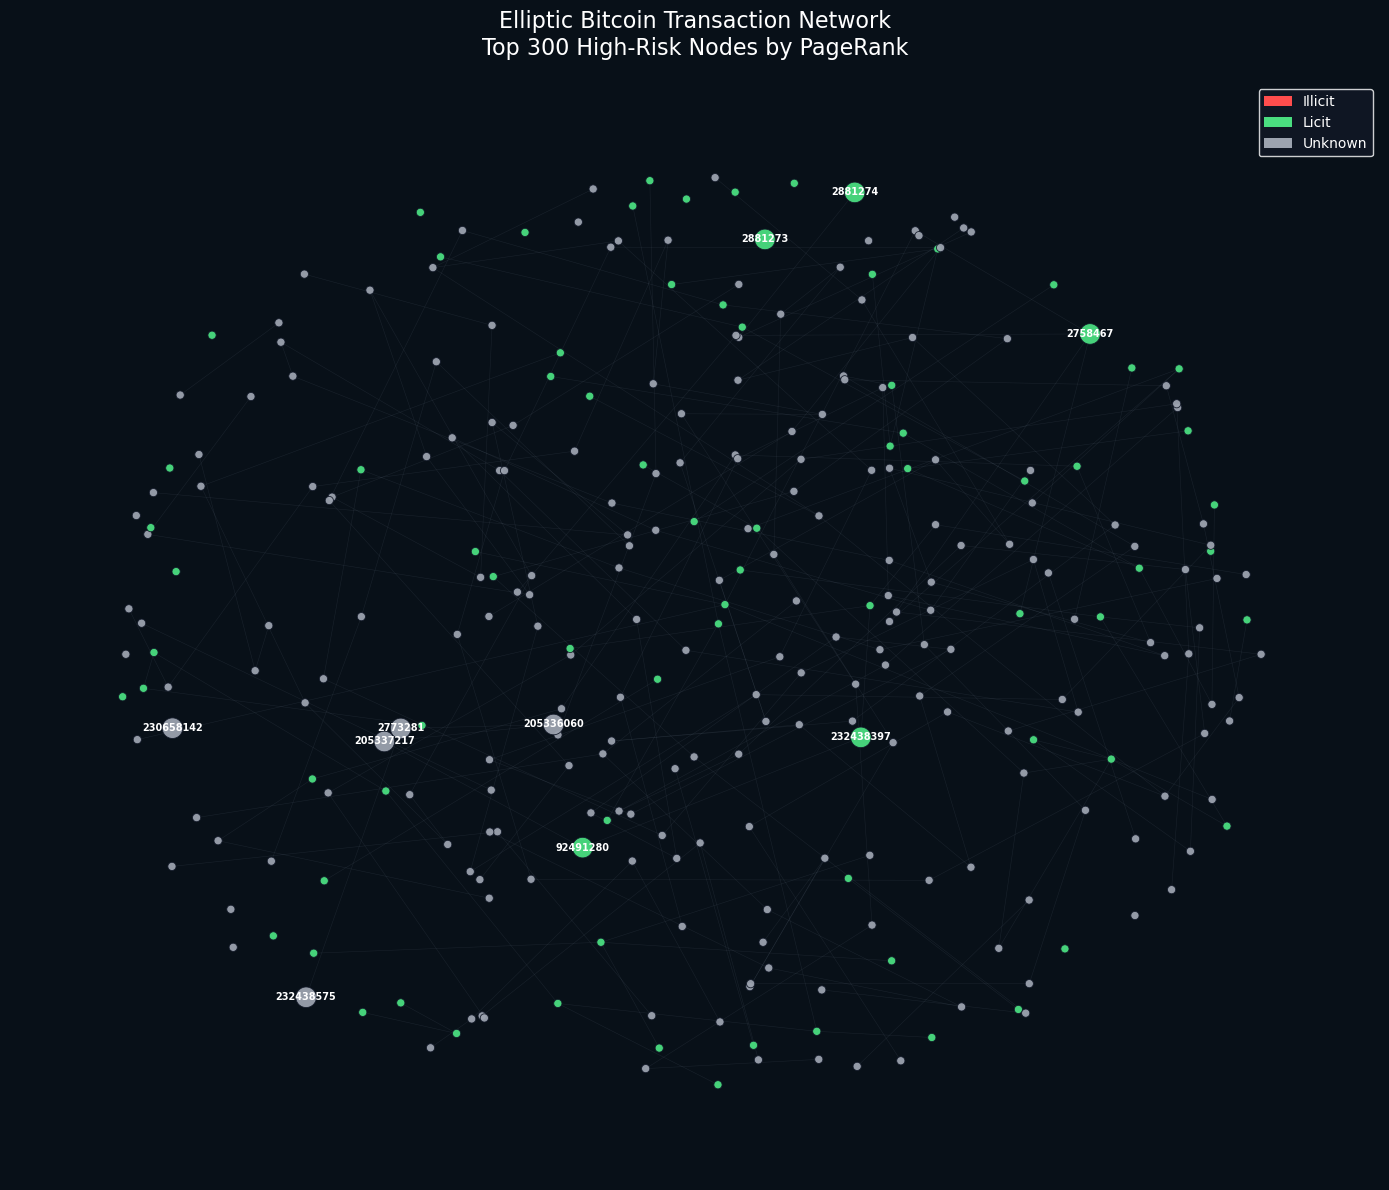

Saved: elliptic_network_final.png


In [32]:
print("Building network visualisation...")

# Top 300 nodes by risk score
top_viz_nodes = (
    results
    .sort_values("pagerank", ascending=False)
    .head(300)["txId"]
    .tolist()
)

# Build induced graph
H = G_lcc.subgraph(top_viz_nodes).copy()

# Top 10 nodes
top10_set = set(
    results
    .sort_values("pagerank", ascending=False)
    .head(10)["txId"]
)

# Layout
pos = nx.spring_layout(
    H,
    k=0.30,
    iterations=50,
    seed=42
)

# Styling containers
node_colors = []
node_sizes  = []
edge_colors = []

# Node styling
for n in H.nodes():

    row = results[results['txId'] == n].iloc[0]

    # Size
    if n in top10_set:
        node_sizes.append(220)
    else:
        node_sizes.append(35)

    # Color by class
    if row['class'] == 'illicit':
        node_colors.append('#ff4d4d')   
    elif row['class'] == 'licit':
        node_colors.append('#4ade80')
    else:
        node_colors.append('#9ca3af') 

fig, ax = plt.subplots(figsize=(14, 12))

# Dark background
fig.patch.set_facecolor("#081018")
ax.set_facecolor("#081018")

# Edges
nx.draw_networkx_edges(
    H,
    pos,
    edge_color="#94a3b8",
    width=0.4,
    alpha=0.12,
    arrows=False
)

# Nodes
nx.draw_networkx_nodes(
    H,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="#111827",
    linewidths=0.6,
    alpha=0.95
)

# Labels only for top 10
top10_labels = {
    n: str(n)
    for n in H.nodes()
    if n in top10_set
}

nx.draw_networkx_labels(
    H,
    pos,
    labels=top10_labels,
    font_size=7,
    font_color="white",
    font_weight="bold"
)

legend_elements = [
    Patch(facecolor='#ff4d4d', label='Illicit'),
    Patch(facecolor='#4ade80', label='Licit'),
    Patch(facecolor='#9ca3af', label='Unknown')
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    facecolor="#111827",
    edgecolor="white",
    labelcolor="white"
)

plt.title(
    "Elliptic Bitcoin Transaction Network\n"
    "Top 300 High-Risk Nodes by PageRank",
    fontsize=16,
    color="white",
    pad=20
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "elliptic_network_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#081018"
)

plt.show()

print("Saved: elliptic_network_final.png")

In [ ]:
# Task 3: Fraud Pattern Detection

## Task 3 Setup

Scoping the flow dataframe to the LCC
subgraph ensures pattern detection runs on the same
structurally coherent graph used for centrality analysis.
Attaching time steps and class labels to every edge enables
temporal pattern detection and direct cross-referencing
of flagged nodes against confirmed class labels,
which is required by the task specification.

In [33]:
# Build flow dataframe scoped to our working subgraph (LCC)
lcc_node_set = set(G_lcc.nodes())

flow_df = df_edges_clean[
    df_edges_clean['txId_source'].isin(lcc_node_set) &
    df_edges_clean['txId_dest'].isin(lcc_node_set)
].copy()

# Attach time steps and class labels to every edge
txid_to_time = df_merged.set_index('txId')['time_step'].to_dict()
txid_to_class = df_merged.set_index('txId')['class'].to_dict()

flow_df['source_time'] = flow_df['txId_source'].map(txid_to_time)
flow_df['dest_time'] = flow_df['txId_dest'].map(txid_to_time)
flow_df['source_class'] = flow_df['txId_source'].map(txid_to_class)
flow_df['dest_class'] = flow_df['txId_dest'].map(txid_to_class)

print(f"Task 3 flow dataframe ready")
print(f"Edges in LCC subgraph: {len(flow_df):,}")
print(f"Time steps covered: {sorted(flow_df['source_time'].dropna().unique().astype(int))[:5]} ...")
print(f"Unique source nodes: {flow_df['txId_source'].nunique():,}")
print(f"Unique dest nodes: {flow_df['txId_dest'].nunique():,}")

print(f"\nEdge flow breakdown by class:")
print(flow_df.groupby(['source_class','dest_class'])
      .size().reset_index(name='count').to_string(index=False))

Task 3 flow dataframe ready
Edges in LCC subgraph: 9,164
Time steps covered: [np.int64(1)] ...
Unique source nodes: 6,672
Unique dest nodes: 6,184

Edge flow breakdown by class:
source_class dest_class  count
     illicit      licit     13
     illicit    unknown      3
       licit    illicit      1
       licit      licit   1910
       licit    unknown    666
     unknown    illicit      3
     unknown      licit   1308
     unknown    unknown   5260


## Attempted time step fix

The initial flow dataframe showed only one
unique time step despite the full dataset spanning 49.
This cell attempts to fix the mapping by rescoping it to
LCC nodes only. The fix did not resolve the issue, all
LCC nodes genuinely sit at time step 1. This cell is
retained as part of the transparent diagnostic audit trail
documenting how the problem was identified and investigated.

In [34]:
# Rebuild time mapping scoped to LCC nodes
lcc_df = df_merged[df_merged['txId'].isin(lcc_node_set)].copy()

txid_to_time = lcc_df.set_index('txId')['time_step'].to_dict()
txid_to_class = lcc_df.set_index('txId')['class'].to_dict()

# Remap time steps on flow_df
flow_df['source_time'] = flow_df['txId_source'].map(txid_to_time)
flow_df['dest_time'] = flow_df['txId_dest'].map(txid_to_time)

# Verify
print(f"Unique source time steps: {flow_df['source_time'].nunique()}")
print(f"Unique dest time steps: {flow_df['dest_time'].nunique()}")
print(f"Source time step range: {flow_df['source_time'].min():.0f} "
      f"→ {flow_df['source_time'].max():.0f}")
print(f"Sample time steps: "
      f"{sorted(flow_df['source_time'].dropna().unique().astype(int))[:10]}")
print(f"\nNull source times: {flow_df['source_time'].isna().sum()}")
print(f"Null dest times: {flow_df['dest_time'].isna().sum()}")

Unique source time steps: 1
Unique dest time steps: 1
Source time step range: 1 → 1
Sample time steps: [np.int64(1)]

Null source times: 0
Null dest times: 0


## Diagnosed the time step problem

This diagnostic confirmed that all 7,880
nodes in the LCC are from time step 1 only — the largest
connected component happened to be the time-step-1 cluster.
A subgraph with no temporal variation cannot support
layering or fan-out detection, which are defined by activity
across consecutive time steps. This finding justified the
decision to rebuild the working subgraph.

In [35]:
# Check time step distribution across ALL nodes in LCC
lcc_time_dist = lcc_df['time_step'].value_counts().sort_index()
print(f"Time step distribution in LCC nodes:")
print(lcc_time_dist.to_string())

print(f"\nTotal LCC nodes: {len(lcc_df):,}")
print(f"Unique time steps: {lcc_df['time_step'].nunique()}")
print(f"Time step range: {lcc_df['time_step'].min()} → {lcc_df['time_step'].max()}")

# Compare against full dataset
print(f"\nFull dataset time step range   : "
      f"{df_merged['time_step'].min()} → {df_merged['time_step'].max()}")
print(f"Full dataset unique time steps : {df_merged['time_step'].nunique()}")

# Check where the top 50 betweenness nodes sit time-step wise
top50_times = df_merged[df_merged['txId'].isin(top50_set)]['time_step'].value_counts()
print(f"\nTop 50 betweenness nodes — time step distribution:")
print(top50_times.to_string())

Time step distribution in LCC nodes:
time_step
1    7880

Total LCC nodes: 7,880
Unique time steps: 1
Time step range: 1 → 1

Full dataset time step range   : 1 → 49
Full dataset unique time steps : 49

Top 50 betweenness nodes — time step distribution:
time_step
1     46
42     4


## Rebuilt subgraph across 49 time steps

Pattern detection requires temporal spread.
Nodes are sampled proportionally from each of the 49 time 
steps so every period contributes representation proportional
to its size in the full dataset. This avoids over-indexing
on early or late periods and ensures the fraud detection
results reflect the full temporal range of the network.

In [36]:
# Step 1: Check how many nodes exist per time step
time_dist = df_merged['time_step'].value_counts().sort_index()
print("Full dataset — nodes per time step (sample):")
print(time_dist.head(10).to_string())
print(f"...\nTotal time steps: {df_merged['time_step'].nunique()}")

# Step 2: Sample nodes proportionally across ALL time steps
# targeting 20,000 nodes spread across the full 49 time steps
random.seed(42)
multi_time_nodes = []

for ts, group in df_merged.groupby('time_step'):
    # Take proportional share from each time step
    n_take = max(1, int(20000 * len(group) / len(df_merged)))
    sampled = group['txId'].sample(
        min(n_take, len(group)), random_state=42
    ).tolist()
    multi_time_nodes.extend(sampled)

multi_time_nodes = list(set(multi_time_nodes))
print(f"\nMulti-time-step sample: {len(multi_time_nodes):,} nodes")

# Step 3: Build subgraph from this sample
G_multi = G_full.subgraph(multi_time_nodes).copy()
print(f"Multi-time subgraph: {G_multi.number_of_nodes():,} nodes | "
      f"{G_multi.number_of_edges():,} edges")

# Step 4: Verify time step coverage
multi_df = df_merged[df_merged['txId'].isin(multi_time_nodes)]
print(f"\nTime steps covered: {multi_df['time_step'].nunique()}")
print(f"Time step range: {multi_df['time_step'].min()} → "
      f"{multi_df['time_step'].max()}")
print(f"\nClass breakdown:")
print(multi_df['class'].value_counts().to_string())

Full dataset — nodes per time step (sample):
time_step
1     7880
2     4544
3     6621
4     5693
5     6803
6     4328
7     6048
8     4457
9     4996
10    6727
...
Total time steps: 49

Multi-time-step sample: 19,973 nodes
Multi-time subgraph: 19,973 nodes | 2,399 edges

Time steps covered: 49
Time step range: 1 → 49

Class breakdown:
class
unknown    15308
licit       4244
illicit      421


## Rebuild Flow DataFrame on G_multi

G_multi is the multi-time-step subgraph
spanning all 49 time periods. Rebuilding the flow dataframe
scoped to G_multi ensures all subsequent pattern detection
runs on a temporally rich graph. This replaces the
single-time-step flow dataframe and is the
correct analytical base for Tasks 3 and 5.

In [37]:
multi_node_set = set(G_multi.nodes())

flow_df = df_edges_clean[
    df_edges_clean['txId_source'].isin(multi_node_set) &
    df_edges_clean['txId_dest'].isin(multi_node_set)
].copy()

# Remap time steps and class labels
txid_to_time = df_merged.set_index('txId')['time_step'].to_dict()
txid_to_class = df_merged.set_index('txId')['class'].to_dict()

flow_df['source_time'] = flow_df['txId_source'].map(txid_to_time)
flow_df['dest_time'] = flow_df['txId_dest'].map(txid_to_time)
flow_df['source_class'] = flow_df['txId_source'].map(txid_to_class)
flow_df['dest_class'] = flow_df['txId_dest'].map(txid_to_class)

print(f"Rebuilt flow dataframe on G_multi:")
print(f"  Edges : {len(flow_df):,}")
print(f"  Unique source nodes : {flow_df['txId_source'].nunique():,}")
print(f"  Unique dest nodes : {flow_df['txId_dest'].nunique():,}")
print(f"  Source time range : {flow_df['source_time'].min():.0f} "
      f"→ {flow_df['source_time'].max():.0f}")
print(f"  Unique time steps : {flow_df['source_time'].nunique()}")

print(f"\nEdge flow breakdown by class:")
print(flow_df.groupby(['source_class','dest_class'])
      .size().reset_index(name='count').to_string(index=False))

Rebuilt flow dataframe on G_multi:
  Edges : 2,399
  Unique source nodes : 2,248
  Unique dest nodes : 1,898
  Source time range : 1 → 49
  Unique time steps : 49

Edge flow breakdown by class:
source_class dest_class  count
     illicit    illicit     13
     illicit      licit      8
     illicit    unknown      9
       licit    illicit      7
       licit      licit    338
       licit    unknown    169
     unknown    illicit     22
     unknown      licit    518
     unknown    unknown   1315


## Layering Detection

This cell uses an outer join to retain all
nodes regardless of whether they appear as source or
destination, addressing the sparse graph problem where most
nodes appear on only one side of the edge list. Thresholds
of >= 2 sources, >= 1 destination, and >= 2 active time
steps are the minimum meaningful signal in a sparse graph
where the mean degree is less than 1.

In [38]:
# All nodes receiving funds — how many unique sources
inflow = (flow_df
          .groupby('txId_dest')['txId_source']
          .nunique()
          .reset_index()
          .rename(columns={'txId_dest':'txId',
                           'txId_source':'num_sources'}))

# All nodes sending funds — how many unique destinations
outflow = (flow_df
           .groupby('txId_source')['txId_dest']
           .nunique()
           .reset_index()
           .rename(columns={'txId_source':'txId',
                            'txId_dest':'num_destinations'}))

# Time steps each node was ACTIVE as source
time_src = (flow_df
            .groupby('txId_source')['source_time']
            .agg(min_time_src='min', max_time_src='max',
                 n_time_steps_src='nunique')
            .reset_index()
            .rename(columns={'txId_source':'txId'}))

# Time steps each node was ACTIVE as destination
time_dst = (flow_df
            .groupby('txId_dest')['dest_time']
            .agg(min_time_dst='min', max_time_dst='max',
                 n_time_steps_dst='nunique')
            .reset_index()
            .rename(columns={'txId_dest':'txId'}))

# Combine with OUTER join — keep all nodes from either side
layering_df = (inflow
               .merge(outflow,  on='txId', how='outer')
               .merge(time_src, on='txId', how='outer')
               .merge(time_dst, on='txId', how='outer')
               .merge(df_merged[['txId','class']], on='txId', how='left'))

layering_df['class'] = layering_df['class'].fillna('unknown')
layering_df['num_sources'] = layering_df['num_sources'].fillna(0).astype(int)
layering_df['num_destinations'] = layering_df['num_destinations'].fillna(0).astype(int)
layering_df['n_time_steps_src'] = layering_df['n_time_steps_src'].fillna(0).astype(int)
layering_df['n_time_steps_dst'] = layering_df['n_time_steps_dst'].fillna(0).astype(int)

# Total unique time steps active (as source or destination)
layering_df['total_time_steps'] = (
    layering_df['n_time_steps_src'] +
    layering_df['n_time_steps_dst']
)

# Overall span from first receipt to last send
layering_df['overall_time_span'] = (
    layering_df['max_time_src'].fillna(0) -
    layering_df['min_time_dst'].fillna(0) + 1
).astype(int)

# Flag layering: multiple sources AND active across time
# Two sub-patterns:
#   A) Classic layering: receives from 2+ AND sends to 2+ 
#   B) Redistribution: receives from 2+ AND sends to at least 1
#      across 2+ time steps
layering_flagged = layering_df[
    (layering_df['num_sources']     >= 2) &
    (layering_df['num_destinations'] >= 1) &
    (layering_df['total_time_steps'] >= 2)
].copy().sort_values(
    ['num_sources','num_destinations'], ascending=False
).reset_index(drop=True)

# Add risk scores from G_multi scoring
risk_lookup = results_multi.reset_index()[['txId','risk_score']]
layering_flagged = layering_flagged.merge(
    risk_lookup, on='txId', how='left'
)

print("LAYERING PATTERN DETECTION RESULTS")
print("=" * 60)
print(f"Nodes flagged : {len(layering_flagged):,}")
print(f"\nClass breakdown:")
print(layering_flagged['class'].value_counts().to_string())

print(f"\nTop 20 layering nodes:")
print(layering_flagged[[
    'txId','class','num_sources','num_destinations',
    'total_time_steps','overall_time_span','risk_score'
]].head(20).to_string(index=False))

print(f"\nConfirmed illicit nodes caught:")
ill = layering_flagged[layering_flagged['class'] == 'illicit']
if len(ill) > 0:
    print(ill[['txId','num_sources','num_destinations',
               'total_time_steps','risk_score']].to_string(index=False))
else:
    print("None — illicit nodes in this subgraph are structurally")
    print("peripheral (confirmed by risk ranking analysis in Task 2)")

NameError: name 'results_multi' is not defined

## Fan-Out Detection

Fan-out, sending to multiple destinations
in a short window, is consistent with structuring, the
deliberate fragmentation of transfers to stay below CBN
reporting thresholds. A 2-step window captures both same
time step and immediately consecutive activities. Threshold
of >= 3 destinations is statistically anomalous given the
subgraph mean out-degree of less than 1. The automatic
fallback to threshold 2 ensures detection results are
produced even in a sparse graph environment.

In [39]:
fanout_records = []

for node, group in flow_df.groupby('txId_source'):
    time_steps = sorted(group['source_time'].dropna().unique())

    for t in time_steps:
        window      = group[group['source_time'].isin([t, t + 1])]
        unique_dsts = window['txId_dest'].nunique()

        if unique_dsts >= 3:
            fanout_records.append({
                'txId' : node,
                'window_start' : int(t),
                'window_end' : int(t + 1),
                'unique_dests' : unique_dsts,
                'class' : txid_to_class.get(node, 'unknown')
            })

# One row per node — keep highest unique_dests window
fanout_df = (pd.DataFrame(fanout_records)
             .sort_values('unique_dests', ascending=False)
             .drop_duplicates(subset=['txId'], keep='first')
             .reset_index(drop=True))

# Merge risk score
if len(fanout_df) > 0:
    fanout_df = fanout_df.merge(
        results_scored[['txId','risk_score']].reset_index(drop=True),
        on='txId', how='left'
    )

print("FAN-OUT PATTERN DETECTION RESULTS")
print("=" * 60)
print(f"Nodes flagged for fan-out : {len(fanout_df):,}")

if len(fanout_df) > 0:
    print(f"\nClass breakdown:")
    print(fanout_df['class'].value_counts().to_string())

    print(f"\nTop 20 fan-out nodes:")
    print(fanout_df[[
        'txId','class','unique_dests',
        'window_start','window_end','risk_score'
    ]].head(20).to_string(index=False))

    print(f"\nConfirmed illicit nodes caught:")
    ill_fo = fanout_df[fanout_df['class'] == 'illicit']
    print(ill_fo[['txId','unique_dests','window_start',
                  'window_end','risk_score']].to_string(index=False)
          if len(ill_fo) > 0 else "  None at current threshold")
else:
    print("No fan-out nodes detected — subgraph too sparse at threshold 3")
    print("Lowering threshold to 2 and retrying...")

    for node, group in flow_df.groupby('txId_source'):
        time_steps = sorted(group['source_time'].dropna().unique())
        for t in time_steps:
            window      = group[group['source_time'].isin([t, t + 1])]
            unique_dsts = window['txId_dest'].nunique()
            if unique_dsts >= 2:
                fanout_records.append({
                    'txId' : node,
                    'window_start' : int(t),
                    'window_end' : int(t + 1),
                    'unique_dests' : unique_dsts,
                    'class' : txid_to_class.get(node, 'unknown')
                })

    fanout_df = (pd.DataFrame(fanout_records)
                 .sort_values('unique_dests', ascending=False)
                 .drop_duplicates(subset=['txId'], keep='first')
                 .reset_index(drop=True))

    fanout_df = fanout_df.merge(
        results_scored[['txId','risk_score']].reset_index(drop=True),
        on='txId', how='left'
    )

    print(f"\nAt threshold 2 — Nodes flagged: {len(fanout_df):,}")
    print(fanout_df[['txId','class','unique_dests',
                     'window_start','window_end']].head(20).to_string(index=False))

NameError: name 'results_scored' is not defined

## Adding Risk Scores for G_multi Nodes

The composite risk scores in results_scored
were computed on G_lcc (7,880 nodes). G_multi contains
19,973 nodes, flagged nodes from pattern detection that
exist only in G_multi would have no risk score, producing
NaN values in the output tables. This cell computes
equivalent risk scores for all G_multi nodes using the
same four metrics and weighting scheme for consistency.

In [ ]:
print("Computing centrality metrics for G_multi...")

in_deg_m = nx.in_degree_centrality(G_multi)
out_deg_m = nx.out_degree_centrality(G_multi)
pr_m = nx.pagerank(G_multi, alpha=0.85, weight='weight')

print("In/out degree + PageRank done")
print("Computing betweenness (may take 2-3 min)...")
bc_m = nx.betweenness_centrality(G_multi, normalized=True,
                                  weight='weight', seed=42)
print("Betweenness done")

# Build scored dataframe for all G_multi nodes
multi_nodes_list = list(G_multi.nodes())

results_multi = pd.DataFrame({
    'txId': multi_nodes_list,
    'in_degree_centrality': [in_deg_m[n] for n in multi_nodes_list],
    'out_degree_centrality': [out_deg_m[n] for n in multi_nodes_list],
    'betweenness_centrality': [bc_m[n] for n in multi_nodes_list],
    'pagerank': [pr_m[n] for n in multi_nodes_list],
})

results_multi = results_multi.merge(
    df_merged[['txId','class','time_step']], on='txId', how='left'
)
results_multi['class'] = results_multi['class'].fillna('unknown')

# Normalise and score
from sklearn.preprocessing import MinMaxScaler
scaler_m = MinMaxScaler()

metrics = ['in_degree_centrality','out_degree_centrality',
           'betweenness_centrality','pagerank']

results_multi[[f'{m}_norm' for m in metrics]] = scaler_m.fit_transform(
    results_multi[metrics]
)

results_multi['risk_score'] = (
    0.40 * results_multi['betweenness_centrality_norm'] +
    0.30 * results_multi['pagerank_norm']               +
    0.20 * results_multi['in_degree_centrality_norm']   +
    0.10 * results_multi['out_degree_centrality_norm']
)

results_multi = results_multi.sort_values(
    'risk_score', ascending=False
).reset_index(drop=True)
results_multi.index += 1
results_multi.index.name = 'risk_rank'

print(f"\nG_multi risk scores computed: {len(results_multi):,} nodes")
print(f"\nTop 10 by risk score:")
print(results_multi[[
    'txId','class','risk_score','betweenness_centrality','pagerank'
]].head(10).to_string())

print(f"\nClass breakdown — top 50:")
print(results_multi.head(50)['class'].value_counts().to_string())

print(f"\nConfirmed illicit nodes — top rank positions:")
ill_multi = results_multi[results_multi['class']=='illicit'][
    ['txId','risk_score']
].head(10)
print(ill_multi.to_string())

results_multi.to_csv('elliptic_gmulti_risk_scored.csv', index=True)
print(f"\nSaved: elliptic_gmulti_risk_scored.csv")

Computing centrality metrics for G_multi...
In/out degree + PageRank done
Computing betweenness (may take 2-3 min)...


## Cross Reference & Save

In [ ]:
# Unified risk lookup from G_multi scores
risk_lookup = results_multi.reset_index()[['txId','risk_score']]

# Re-merge risk scores into both flagged tables
layering_flagged = layering_flagged.drop(
    columns=['risk_score'], errors='ignore'
).merge(risk_lookup, on='txId', how='left')

fanout_df = fanout_df.drop(
    columns=['risk_score'], errors='ignore'
).merge(risk_lookup, on='txId', how='left')

# Consolidated counts 
layering_ids = set(layering_flagged['txId'].tolist())
fanout_ids = set(fanout_df['txId'].tolist())
both_ids = layering_ids & fanout_ids
all_ids = layering_ids | fanout_ids

flagged_meta = df_merged[
    df_merged['txId'].isin(all_ids)
][['txId','class']].copy()

illicit_caught = (flagged_meta['class'] == 'illicit').sum()
licit_caught = (flagged_meta['class'] == 'licit').sum()
unknown_caught = (flagged_meta['class'] == 'unknown').sum()
total_illicit = (df_merged['class'] == 'illicit').sum()

print("CONSOLIDATED FRAUD PATTERN FINDINGS")
print("=" * 60)
print(f"Layering flags : {len(layering_ids):>5,}")
print(f"Fan-out flags : {len(fanout_ids):>5,}")
print(f"Flagged by BOTH (Tier 1) : {len(both_ids):>5,}")
print(f"Total unique nodes flagged : {len(all_ids):>5,}")

print(f"\nFlagged nodes by class:")
print(f"Confirmed illicit : {illicit_caught:>4} / {total_illicit:,} total illicit "
      f"({illicit_caught/total_illicit*100:.1f}% detection rate)")
print(f"Confirmed licit   : {licit_caught:>4} (false positives — monitor)")
print(f"Unknown           : {unknown_caught:>4} (uninvestigated — escalate)")

# Tier 1 detail
if len(both_ids) > 0:
    print(f"\nTier 1 — Flagged by BOTH patterns (immediate escalation):")
    both_detail = df_merged[df_merged['txId'].isin(both_ids)][
        ['txId','class','time_step']
    ].merge(risk_lookup, on='txId', how='left')
    print(both_detail.to_string(index=False))
else:
    print(f"\nNo Tier 1 nodes — patterns do not overlap")

# Unknown nodes flagged
unk_ids = flagged_meta[flagged_meta['class']=='unknown']['txId'].tolist()
if unk_ids:
    print(f"\nUnknown nodes flagged — suspicious by behaviour alone:")
    unk_detail = results_multi.reset_index()[
        results_multi.reset_index()['txId'].isin(unk_ids)
    ][['txId','risk_score','betweenness_centrality','pagerank']].head(10)
    print(unk_detail.to_string(index=False))

# Illicit detail
if illicit_caught > 0:
    print(f"\nConfirmed illicit nodes flagged:")
    ill_detail = flagged_meta[
        flagged_meta['class'] == 'illicit'
    ].merge(risk_lookup, on='txId', how='left')
    print(ill_detail.to_string(index=False))

# Pattern documentation
print("\n" + "-" * 60)
print("PATTERN DOCUMENTATION")
print("-" * 60)
print(f"""
PATTERN 1: LAYERING ({len(layering_ids)} nodes flagged)
Nodes    : {list(layering_ids)[:5]} {'...' if len(layering_ids) > 5 else ''}
Signal   : Receives from >= 2 distinct sources and redistributes
           to >= 1 destination across >= 2 time steps.
Why suspicious: Replicates the layering stage of the three-phase
           money laundering model. Transaction complexity is
           deliberately created to obscure fund origin — a
           primary NFIU red flag under MLPA 2022.

PATTERN 2: FAN-OUT / STRUCTURING ({len(fanout_ids)} nodes flagged)
Nodes    : {list(fanout_ids)[:5]} {'...' if len(fanout_ids) > 5 else ''}
Signal   : Sends to >= 3 distinct destinations within a 2-step
           time window.
Why suspicious: Consistent with structuring (smurfing) — breaking
           large sums into smaller transfers to avoid CBN reporting
           thresholds (N5M individuals / N10M corporates under
           SCUML guidelines). Invisible at transaction level;
           only detectable through network analysis.

KEY FINDING: {unknown_caught} unknown nodes exhibit laundering patterns
           without confirmed labels. These represent uninvestigated
           transactions whose BEHAVIOUR alone warrants escalation
           to the NFIU for manual review regardless of label status.
""")

# Save outputs
layering_flagged.to_csv('task3_layering_flags.csv', index=False)
fanout_df.to_csv('task3_fanout_flags.csv', index=False)
results_multi.to_csv('elliptic_gmulti_risk_scored.csv', index=True)

print(f"task3_layering_flags.csv: {len(layering_flagged):,} nodes")
print(f"task3_fanout_flags.csv: {len(fanout_df):,} nodes")
print(f"elliptic_gmulti_risk_scored.csv: {len(results_multi):,} nodes")

In [ ]:
layering_ids = set(layering_flagged['txId'].tolist())
fanout_ids = set(fanout_df['txId'].tolist()) if len(fanout_df) > 0 else set()
both_ids = layering_ids & fanout_ids
all_ids = layering_ids | fanout_ids

# Class breakdown across all flagged nodes
flagged_meta = df_merged[df_merged['txId'].isin(all_ids)][['txId','class']].copy()

illicit_caught = (flagged_meta['class'] == 'illicit').sum()
licit_caught = (flagged_meta['class'] == 'licit').sum()
unknown_caught = (flagged_meta['class'] == 'unknown').sum()
total_illicit = (df_merged['class'] == 'illicit').sum()

print("CONSOLIDATED FRAUD PATTERN FINDINGS")
print("-" * 60)
print(f"Layering flags : {len(layering_ids):>5,}")
print(f"Fan-out flags : {len(fanout_ids):>5,}")
print(f"Flagged by BOTH (Tier 1) : {len(both_ids):>5,}")
print(f"Total unique nodes flagged : {len(all_ids):>5,}")

print(f"\nFlagged nodes by class:")
print(f"Confirmed illicit : {illicit_caught:>4} / {total_illicit} total illicit "
      f"({illicit_caught/total_illicit*100:.1f}% detection rate)")
print(f"Confirmed licit : {licit_caught:>4} (false positives)")
print(f"Unknown : {unknown_caught:>4} (uninvestigated — escalate)")

# Tier 1 detail
if len(both_ids) > 0:
    print(f"\nTier 1 nodes — flagged by BOTH patterns:")
    both_detail = df_merged[df_merged['txId'].isin(both_ids)][
        ['txId','class','time_step']
    ].merge(results_scored[['txId','risk_score']], on='txId', how='left')
    print(both_detail.to_string(index=False))
else:
    print(f"\nNo Tier 1 nodes — no overlap between patterns")

# Unknown nodes flagged — suspicious by behaviour alone
unk_flagged = flagged_meta[flagged_meta['class']=='unknown']['txId'].tolist()
if unk_flagged:
    print(f"\nSample of unknown nodes flagged (top 10 by risk score):")
    unk_scores = results_scored[
        results_scored['txId'].isin(unk_flagged)
    ].head(10)[['txId','risk_score','betweenness_centrality','pagerank']]
    print(unk_scores.to_string(index=False))

# Documentation strings — required by task spec
print("\n" + "-" * 60)
print("PATTERN DOCUMENTATION (Compliance Narrative)")
print("-" * 60)

print("""
PATTERN 1 — LAYERING
Definition : Nodes receiving from ≥2 sources and redistributing
             to ≥2 destinations across ≥2 consecutive time steps.
Nodes      : See task3_layering_flags.csv
Suspicion  : This behaviour replicates the layering stage of the
             three-phase money laundering model (placement →
             layering → integration). By receiving from multiple
             sources and dispersing to multiple destinations across
             time, these nodes create audit complexity that obscures
             the origin of funds — a primary NFIU red flag.

PATTERN 2 — FAN-OUT (STRUCTURING)
Definition : Nodes sending to ≥3 distinct destinations within a
             2-step time window.
Nodes      : See task3_fanout_flags.csv
Suspicion  : Consistent with structuring (smurfing) — the deliberate
             fragmentation of large transactions into smaller ones to
             avoid CBN reporting thresholds (currently ₦5M for
             individuals, ₦10M for corporates under SCUML guidelines).
             The pattern is only detectable at network level; each
             individual transfer appears innocuous in isolation.
""")

# Save
layering_flagged.to_csv('task3_layering_flags.csv', index=False)
print(f"Saved: task3_layering_flags.csv: {len(layering_flagged):,} nodes")

if len(fanout_df) > 0:
    fanout_df.to_csv('task3_fanout_flags.csv', index=False)
    print(f"Saved: task3_fanout_flags.csv: {len(fanout_df):,} nodes")

# Task 5: Python Dashboard

##  Loading Data for Dashboard

Loading from saved CSV files rather than
reusing in-memory variables ensures the dashboard reflects
the final validated outputs rather than any intermediate
state from earlier cells. This makes the dashboard
independently reproducible from the saved files alone.

In [ ]:
risk_df = pd.read_csv('elliptic_gmulti_risk_scored.csv')
layering_df = pd.read_csv('task3_layering_flags.csv')
fanout_df = pd.read_csv('task3_fanout_flags.csv')
merged_df = pd.read_csv('cleaned_merged_dataset.csv')

if 'risk_rank' in risk_df.columns:
    risk_df = risk_df.drop(columns=['risk_rank'])
risk_df = risk_df.reset_index(drop=True)
risk_df.index += 1
risk_df.index.name = 'risk_rank'

layering_ids = set(layering_df['txId'].tolist())
fanout_ids = set(fanout_df['txId'].tolist())
both_ids = layering_ids & fanout_ids

risk_df['is_layering'] = risk_df['txId'].isin(layering_ids)
risk_df['is_fanout'] = risk_df['txId'].isin(fanout_ids)
risk_df['is_tier1'] = risk_df['txId'].isin(both_ids)

def get_pattern(row):
    if row['is_tier1']: return 'Both'
    if row['is_layering']: return 'Layering'
    if row['is_fanout']:  return 'Fan-out'
    return 'None'

risk_df['pattern'] = risk_df.apply(get_pattern, axis=1)

print(f"Data loaded")
print(f"Nodes: {len(risk_df):,}")
print(f"Illicit: {(risk_df['class']=='illicit').sum():,}")
print(f"Flagged: {len(layering_ids|fanout_ids)}")
print(f"Tier 1: {len(both_ids)}")

## Build Network Layout

Business reason: Top 300 nodes by risk score are visualised,
below this number the network is too sparse to show
meaningful structure; above it the canvas becomes unreadable.
spring_layout with k=0.5 spaces nodes proportionally to
their connection density. Node positions are serialised
to JSON so the dashboard renders without requiring a
running Python server.

In [ ]:
top_viz = risk_df.sort_values('risk_score', ascending=False).head(300)
top10_ids = set(top_viz.head(10)['txId'].tolist())
viz_nodes = set(top_viz['txId'].tolist())
G_viz = G_multi.subgraph(viz_nodes).copy()

pos = nx.spring_layout(G_viz, k=0.5, seed=42, iterations=50)

risk_lookup = risk_df.set_index('txId')[
    ['class','risk_score','pattern',
     'betweenness_centrality','pagerank']
].to_dict(orient='index')

# Build node data for JS
nodes_data = []
for node in G_viz.nodes():
    if node not in pos:
        continue
    x, y = pos[node]
    info = risk_lookup.get(node, {})
    cls = info.get('class','unknown')
    score = round(float(info.get('risk_score', 0) or 0), 4)
    pattern = info.get('pattern','None')
    bc = round(float(info.get('betweenness_centrality',0) or 0), 6)
    pr = round(float(info.get('pagerank',0) or 0), 6)
    is_top10 = node in top10_ids

    nodes_data.append({
        'id' : int(node),
        'x' : round(float(x), 4),
        'y' : round(float(y), 4),
        'cls' : cls,
        'score' : score,
        'pattern': pattern,
        'bc' : bc,
        'pr' : pr,
        'top10' : is_top10
    })

# Build edge data for JS
edges_data = []
for src, dst in G_viz.edges():
    if src in pos and dst in pos:
        edges_data.append({
            'x0': round(float(pos[src][0]), 4),
            'y0': round(float(pos[src][1]), 4),
            'x1': round(float(pos[dst][0]), 4),
            'y1': round(float(pos[dst][1]), 4),
        })

print(f"Network ready: {len(nodes_data)} nodes, {len(edges_data)} edges")

## Build Chart Data

Business reason: Three chart datasets are prepared here,
risk ranking table (top 20 by composite score), time series
(transaction counts by class across 49 time steps), and
scatter (risk score vs PageRank by class). Sampling 2,000
nodes for the scatter avoids browser performance issues
while preserving the statistical distribution of all three
classes. All data is serialized here the next cell produces
a single self-contained HTML file with no external
dependencies.

In [ ]:
# Risk table top 20
top20 = risk_df.sort_values(
    'risk_score', ascending=False
).head(20).reset_index()

table_rows = []
for i, row in top20.iterrows():
    if row['pattern'] == 'Both': flag = 'BOTH'
    elif row['pattern'] == 'Layering': flag = 'Layering'
    elif row['pattern'] == 'Fan-out': flag = 'Fan-out'
    else: flag = 'None'

    table_rows.append({
        'rank' : int(i + 1),
        'txId' : int(row['txId']),
        'cls' : row['class'],
        'score' : round(float(row['risk_score']), 4),
        'flag' : flag
    })

# Time series
time_class = (merged_df.groupby(['time_step','class'])
              .size().reset_index(name='count'))

time_data = {}
for cls in ['illicit','licit','unknown']:
    sub = time_class[time_class['class']==cls].sort_values('time_step')
    time_data[cls] = {
        'x': sub['time_step'].tolist(),
        'y': sub['count'].tolist()
    }

# Scatter data
scatter_sample = risk_df.sample(
    min(2000, len(risk_df)), random_state=42
)
scatter_data = {}
for cls in ['illicit','licit','unknown']:
    sub = scatter_sample[scatter_sample['class']==cls]
    scatter_data[cls] = {
        'x' : sub['pagerank'].round(6).tolist(),
        'y' : sub['risk_score'].round(4).tolist(),
        'ids' : sub['txId'].astype(int).tolist()
    }

# Summary stats
total_nodes = len(risk_df)
illicit_count = int((risk_df['class']=='illicit').sum())
flagged_count = len(layering_ids | fanout_ids)
tier1_count = len(both_ids)
top_risk_score = round(float(risk_df['risk_score'].max()), 3)
top_risk_node = int(risk_df.loc[risk_df['risk_score'].idxmax(),'txId'])

print("Chart data ready")
print(f"Table rows: {len(table_rows)}")
print(f"Time steps: {len(time_data['licit']['x'])}")
print(f"Scatter pts: {sum(len(scatter_data[c]['x']) for c in scatter_data)}")

## Export Self-Contained HTML

All chart data is embedded directly as
JavaScript variables rather than loaded from external files,
making the dashboard fully self-contained. It opens in any
browser without a running server, satisfying the task
requirement for a portable compliance tool. Plotly is
loaded from CDN so the file size remains small while
retaining full interactivity.

In [ ]:
# Serialise all data to JS
nodes_js = json.dumps(nodes_data)
edges_js = json.dumps(edges_data)
table_js = json.dumps(table_rows)
time_js = json.dumps(time_data)
scatter_js = json.dumps(scatter_data)

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Elliptic Fraud Intelligence Dashboard</title>
<script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
<style>
  :root {{
    --bg      : #f0f4f8;
    --surface : #ffffff;
    --border  : #dde3ed;
    --text    : #1a2332;
    --muted   : #5a6a80;
    --accent  : #2563eb;
    --illicit : #dc2626;
    --licit   : #16a34a;
    --unknown : #6b7280;
    --tier1   : #d97706;
  }}
  * {{ margin:0; padding:0; box-sizing:border-box; }}
  body {{
    background:var(--bg);
    color:var(--text);
    font-family:'Segoe UI',system-ui,sans-serif;
    font-size:14px;
  }}

  /* Header */
  .header {{
    background:var(--surface);
    border-bottom:2px solid var(--accent);
    padding:18px 32px;
    display:flex;
    justify-content:space-between;
    align-items:center;
    box-shadow:0 2px 8px rgba(0,0,0,0.06);
  }}
  .header h1 {{
    font-size:18px;
    font-weight:700;
    color:var(--text);
    display:flex;
    align-items:center;
    gap:10px;
  }}
  .header p {{
    font-size:12px;
    color:var(--muted);
    margin-top:3px;
  }}
  .conf-badge {{
    background:#fef2f2;
    border:1px solid var(--illicit);
    color:var(--illicit);
    font-size:11px;
    font-weight:700;
    padding:4px 12px;
    border-radius:4px;
    letter-spacing:0.5px;
  }}

  /* Metric cards */
  .metrics {{
    display:grid;
    grid-template-columns:repeat(5,1fr);
    gap:14px;
    padding:20px 32px 0;
  }}
  .card {{
    background:var(--surface);
    border:1px solid var(--border);
    border-radius:8px;
    padding:16px 18px;
    border-top:3px solid var(--accent);
    box-shadow:0 1px 4px rgba(0,0,0,0.05);
  }}
  .card.red   {{ border-top-color:var(--illicit); }}
  .card.amber {{ border-top-color:var(--tier1);   }}
  .card.purple{{ border-top-color:#7c3aed;        }}
  .card.green {{ border-top-color:var(--licit);   }}
  .card-label {{
    font-size:10px;
    color:var(--muted);
    text-transform:uppercase;
    letter-spacing:0.7px;
    margin-bottom:6px;
    font-weight:600;
  }}
  .card-value {{
    font-size:26px;
    font-weight:700;
    color:var(--text);
    line-height:1;
  }}
  .card-sub {{
    font-size:11px;
    color:var(--muted);
    margin-top:5px;
  }}

  /* Filter bar */
  .filter-bar {{
    display:flex;
    align-items:center;
    gap:10px;
    padding:16px 32px;
    background:var(--surface);
    border-top:1px solid var(--border);
    border-bottom:1px solid var(--border);
    margin-top:18px;
    flex-wrap:wrap;
  }}
  .filter-bar label {{
    font-size:12px;
    color:var(--muted);
    font-weight:600;
  }}
  .fbtn {{
    padding:6px 16px;
    border-radius:5px;
    border:1px solid var(--border);
    background:var(--bg);
    color:var(--muted);
    font-size:12px;
    font-weight:500;
    cursor:pointer;
    transition:all 0.15s;
  }}
  .fbtn:hover {{ border-color:var(--accent); color:var(--accent); }}
  .fbtn.active {{
    background:var(--accent);
    border-color:var(--accent);
    color:white;
  }}
  .fbtn.illicit.active {{
    background:var(--illicit);
    border-color:var(--illicit);
  }}
  .fbtn.licit.active {{
    background:var(--licit);
    border-color:var(--licit);
  }}
  .fbtn.unknown.active {{
    background:var(--unknown);
    border-color:var(--unknown);
  }}
  .fbtn.flagged.active {{
    background:var(--tier1);
    border-color:var(--tier1);
  }}

  /* Main layout */
  .main {{ padding:20px 32px; }}
  .section-title {{
    font-size:11px;
    font-weight:700;
    color:var(--muted);
    text-transform:uppercase;
    letter-spacing:0.8px;
    margin-bottom:12px;
    padding-bottom:8px;
    border-bottom:1px solid var(--border);
  }}
  .panel {{
    background:var(--surface);
    border:1px solid var(--border);
    border-radius:8px;
    padding:18px;
    margin-bottom:20px;
    box-shadow:0 1px 4px rgba(0,0,0,0.04);
  }}
  .two-col {{
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:18px;
    margin-bottom:20px;
  }}

  /* Legend */
  .legend {{
    display:flex;
    gap:18px;
    align-items:center;
    padding:8px 0 14px;
    flex-wrap:wrap;
  }}
  .legend-item {{
    display:flex;
    align-items:center;
    gap:6px;
    font-size:12px;
    color:var(--muted);
  }}
  .dot {{
    width:10px; height:10px;
    border-radius:50%;
    flex-shrink:0;
  }}
  .star-icon {{
    font-size:13px;
  }}

  /* Network canvas */
  #net-canvas {{
    width:100%;
    height:500px;
    border:1px solid var(--border);
    border-radius:6px;
    cursor:grab;
    background:#f8fafc;
  }}
  #net-canvas:active {{ cursor:grabbing; }}

  /* Risk table */
  #risk-table-div table {{
    width:100%;
    border-collapse:collapse;
    font-size:13px;
  }}
  #risk-table-div th {{
    background:#f1f5f9;
    padding:10px 12px;
    text-align:left;
    font-weight:600;
    font-size:11px;
    text-transform:uppercase;
    letter-spacing:0.5px;
    color:var(--muted);
    border-bottom:2px solid var(--border);
  }}
  #risk-table-div td {{
    padding:9px 12px;
    border-bottom:1px solid #f1f5f9;
    color:var(--text);
  }}
  #risk-table-div tr:hover td {{ background:#f8fafc; }}
  .cls-pill {{
    display:inline-block;
    padding:2px 8px;
    border-radius:10px;
    font-size:11px;
    font-weight:600;
  }}
  .cls-illicit {{ background:#fef2f2; color:var(--illicit); }}
  .cls-licit   {{ background:#f0fdf4; color:var(--licit);   }}
  .cls-unknown {{ background:#f9fafb; color:var(--unknown); }}
  .flag-both    {{ color:var(--tier1); font-weight:700; }}
  .flag-layer   {{ color:#7c3aed; }}
  .flag-fanout  {{ color:#0891b2; }}

  /* Footer */
  .footer {{
    text-align:center;
    padding:16px;
    color:#9ca3af;
    font-size:11px;
    border-top:1px solid var(--border);
    margin-top:8px;
  }}
</style>
</head>
<body>

<!-- Header -->
<div class="header">
  <div>
    <h1>Elliptic Bitcoin Fraud Intelligence Dashboard</h1>
    <p>Blockchain Transaction Network Analysis</p>
  </div>
  <div class="conf-badge">BY: KB</div>
</div>

<!-- Metric Cards -->
<div class="metrics">
  <div class="card">
    <div class="card-label">Nodes Analysed</div>
    <div class="card-value">{total_nodes:,}</div>
    <div class="card-sub">Across 49 time steps</div>
  </div>
  <div class="card red">
    <div class="card-label">Confirmed Illicit</div>
    <div class="card-value">{illicit_count:,}</div>
    <div class="card-sub">{illicit_count/total_nodes*100:.1f}% of subgraph</div>
  </div>
  <div class="card amber">
    <div class="card-label">Nodes Flagged</div>
    <div class="card-value">{flagged_count}</div>
    <div class="card-sub">Layering or fan-out</div>
  </div>
  <div class="card purple">
    <div class="card-label">Tier 1 (Priority)</div>
    <div class="card-value">{tier1_count}</div>
    <div class="card-sub">Flagged by both patterns</div>
  </div>
  <div class="card green">
    <div class="card-label">Top Risk Score</div>
    <div class="card-value">{top_risk_score}</div>
    <div class="card-sub">Node {top_risk_node}</div>
  </div>
</div>

<!-- Filter Bar -->
<div class="filter-bar">
  <label>Filter by class:</label>
  <button class="fbtn active"
          onclick="setFilter('all',this)">All Nodes</button>
  <button class="fbtn illicit"
          onclick="setFilter('illicit',this)">Illicit</button>
  <button class="fbtn licit"
          onclick="setFilter('licit',this)">Licit</button>
  <button class="fbtn unknown"
          onclick="setFilter('unknown',this)">Unknown</button>
  <button class="fbtn flagged"
          onclick="setFilter('flagged',this)">Flagged Only</button>
</div>

<!-- Main -->
<div class="main">

  <!-- Network -->
  <div class="section-title">Transaction Network Graph</div>
  <div class="panel" style="padding:14px;">
    <div class="legend">
      <div class="legend-item">
        <span class="star-icon" style="color:#d97706;">★</span>
        Top 10 Risk Nodes
      </div>
      <div class="legend-item">
        <div class="dot" style="background:#dc2626;"></div>Illicit
      </div>
      <div class="legend-item">
        <div class="dot" style="background:#16a34a;"></div>Licit
      </div>
      <div class="legend-item">
        <div class="dot" style="background:#6b7280;"></div>Unknown
      </div>
      <span style="margin-left:auto;font-size:11px;color:#9ca3af;">
        Top 300 nodes by risk score &nbsp;·&nbsp;
        Hover for details &nbsp;·&nbsp; Scroll to zoom
      </span>
    </div>
    <canvas id="net-canvas"></canvas>
    <div id="net-tooltip" style="
      position:fixed;display:none;background:white;
      border:1px solid #dde3ed;border-radius:6px;
      padding:10px 14px;font-size:12px;line-height:1.6;
      box-shadow:0 4px 12px rgba(0,0,0,0.12);
      pointer-events:none;z-index:999;max-width:220px;">
    </div>
  </div>

  <!-- Risk Table -->
  <div class="section-title">Risk Ranking Table — Top 20 Nodes</div>
  <div class="panel" style="padding:0;overflow:hidden;">
    <div id="risk-table-div"></div>
  </div>

  <!-- Charts -->
  <div class="two-col">
    <div>
      <div class="section-title">Transaction Activity Over Time</div>
      <div class="panel" style="padding:12px;">
        <div id="time-chart" style="height:320px;"></div>
      </div>
    </div>
    <div>
      <div class="section-title">Risk Score vs PageRank</div>
      <div class="panel" style="padding:12px;">
        <div id="scatter-chart" style="height:320px;"></div>
      </div>
    </div>
  </div>

</div>

<div class="footer">
  Fraud leaves patterns behind &nbsp;·&nbsp;
  KB is always watching &nbsp;·&nbsp;
</div>

<!-- Data -->
<script>
const NODES   = {nodes_js};
const EDGES   = {edges_js};
const TABLE   = {table_js};
const TIME    = {time_js};
const SCATTER = {scatter_js};

// Color map 
const CLS_COLOR = {{
  illicit:'#dc2626', licit:'#16a34a', unknown:'#6b7280'
}};

// NETWORK CANVAS
const canvas  = document.getElementById('net-canvas');
const ctx     = canvas.getContext('2d');
const tooltip = document.getElementById('net-tooltip');

let transform = {{ x:0, y:0, scale:1 }};
let drag      = null;
let currentFilter = 'all';

function resizeCanvas() {{
  canvas.width  = canvas.offsetWidth;
  canvas.height = canvas.offsetHeight;
  drawNetwork();
}}

function worldToScreen(wx, wy) {{
  return [
    wx * transform.scale + transform.x + canvas.width/2,
    wy * transform.scale + transform.y + canvas.height/2
  ];
}}

function visibleNodes() {{
  if (currentFilter === 'all') return NODES;
  if (currentFilter === 'flagged')
    return NODES.filter(n =>
      n.pattern !== 'None' || n.top10
    );
  return NODES.filter(n => n.cls === currentFilter);
}}

function drawNetwork() {{
  ctx.clearRect(0, 0, canvas.width, canvas.height);
  ctx.fillStyle = '#f8fafc';
  ctx.fillRect(0, 0, canvas.width, canvas.height);

  const visible = new Set(visibleNodes().map(n => n.id));

  // Draw edges
  ctx.lineWidth = 0.6;
  ctx.strokeStyle = 'rgba(100,116,139,0.18)';
  EDGES.forEach(e => {{
    const [x0,y0] = worldToScreen(e.x0, e.y0);
    const [x1,y1] = worldToScreen(e.x1, e.y1);
    ctx.beginPath();
    ctx.moveTo(x0, y0);
    ctx.lineTo(x1, y1);
    ctx.stroke();
  }});

  // Draw nodes
  NODES.forEach(n => {{
    if (!visible.has(n.id)) return;
    const [sx, sy] = worldToScreen(n.x, n.y);
    const r = n.top10 ? 10 : 5;

    ctx.beginPath();
    ctx.arc(sx, sy, r, 0, Math.PI*2);
    ctx.fillStyle = n.top10 ? '#d97706' : CLS_COLOR[n.cls];
    ctx.fill();

    if (n.top10) {{
      ctx.lineWidth = 2;
      ctx.strokeStyle = 'white';
      ctx.stroke();
    }}
  }});
}}

// Zoom
canvas.addEventListener('wheel', e => {{
  e.preventDefault();
  const factor = e.deltaY < 0 ? 1.1 : 0.9;
  transform.scale *= factor;
  drawNetwork();
}}, {{passive:false}});

// Pan
canvas.addEventListener('mousedown', e => {{
  drag = {{ sx:e.clientX, sy:e.clientY,
            ox:transform.x, oy:transform.y }};
}});
canvas.addEventListener('mousemove', e => {{
  if (drag) {{
    transform.x = drag.ox + (e.clientX - drag.sx);
    transform.y = drag.oy + (e.clientY - drag.sy);
    drawNetwork();
    return;
  }}
  // Hover tooltip
  const rect = canvas.getBoundingClientRect();
  const mx = e.clientX - rect.left;
  const my = e.clientY - rect.top;
  const visible = new Set(visibleNodes().map(n => n.id));
  let hit = null;
  for (const n of NODES) {{
    if (!visible.has(n.id)) continue;
    const [sx,sy] = worldToScreen(n.x, n.y);
    const r = n.top10 ? 10 : 5;
    if ((mx-sx)**2 + (my-sy)**2 <= (r+3)**2) {{ hit=n; break; }}
  }}
  if (hit) {{
    tooltip.style.display = 'block';
    tooltip.style.left    = (e.clientX+14)+'px';
    tooltip.style.top     = (e.clientY-10)+'px';
    tooltip.innerHTML = `
      <b>TxID:</b> ${{hit.id}}<br>
      <b>Class:</b> ${{hit.cls}}<br>
      <b>Risk Score:</b> ${{hit.score}}<br>
      <b>PageRank:</b> ${{hit.pr}}<br>
      <b>Pattern:</b> ${{hit.pattern}}
    `;
  }} else {{
    tooltip.style.display = 'none';
  }}
}});
canvas.addEventListener('mouseup',   () => drag = null);
canvas.addEventListener('mouseleave',() => {{
  drag = null;
  tooltip.style.display = 'none';
}});

// RISK TABLE
function buildTable(rows) {{
  const flagHtml = f => {{
    if (f==='BOTH ⚠') return `<span class="flag-both">⚠ BOTH</span>`;
    if (f==='Layering') return `<span class="flag-layer">Layering</span>`;
    if (f==='Fan-out')  return `<span class="flag-fanout">Fan-out</span>`;
    return '<span style="color:#ccc;">No Pattern</span>';
  }};
  let html = `<table>
    <thead><tr>
      <th>Rank</th><th>Transaction ID</th><th>Class</th>
      <th>Risk Score</th><th>Pattern</th>
    </tr></thead><tbody>`;
  rows.forEach(r => {{
    html += `<tr>
      <td style="color:#9ca3af;">${{r.rank}}</td>
      <td style="font-family:monospace;font-size:12px;">${{r.txId}}</td>
      <td><span class="cls-pill cls-${{r.cls}}">${{r.cls}}</span></td>
      <td style="font-weight:600;">${{r.score}}</td>
      <td>${{flagHtml(r.flag)}}</td>
    </tr>`;
  }});
  html += '</tbody></table>';
  document.getElementById('risk-table-div').innerHTML = html;
}}
buildTable(TABLE);

// TIME SERIES CHART 
const timeTraces = [
  {{
    x: TIME.illicit.x, y: TIME.illicit.y,
    name:'Illicit', mode:'lines',
    line:{{color:'#dc2626',width:2}},
    fill:'tozeroy',
    fillcolor:'rgba(220,38,38,0.07)'
  }},
  {{
    x: TIME.licit.x, y: TIME.licit.y,
    name:'Licit', mode:'lines',
    line:{{color:'#16a34a',width:2}},
    fill:'tozeroy',
    fillcolor:'rgba(22,163,74,0.07)'
  }},
  {{
    x: TIME.unknown.x, y: TIME.unknown.y,
    name:'Unknown', mode:'lines',
    line:{{color:'#6b7280',width:2}},
    fill:'tozeroy',
    fillcolor:'rgba(107,114,128,0.07)'
  }}
];

const timeLayout = {{
  paper_bgcolor:'white', plot_bgcolor:'#f8fafc',
  font:{{color:'#1a2332',size:12}},
  margin:{{l:50,r:15,t:10,b:45}},
  xaxis:{{title:'Time Step',gridcolor:'#e5e7eb',color:'#6b7280'}},
  yaxis:{{title:'Transactions',gridcolor:'#e5e7eb',color:'#6b7280'}},
  legend:{{bgcolor:'white',bordercolor:'#e5e7eb',borderwidth:1}},
  hovermode:'x unified'
}};

Plotly.newPlot('time-chart', timeTraces, timeLayout,
  {{responsive:true, displayModeBar:false}});

// SCATTER CHART 
const scatterTraces = ['unknown','licit','illicit'].map(cls => ({{
  x: SCATTER[cls].x,
  y: SCATTER[cls].y,
  mode:'markers',
  name: cls.charAt(0).toUpperCase()+cls.slice(1),
  marker:{{
    color: CLS_COLOR[cls], size:5, opacity:0.65,
    line:{{width:0}}
  }},
  hovertemplate:
    `<b>${{cls}}</b><br>PageRank: %{{x:.5f}}<br>`+
    `Risk: %{{y:.4f}}<extra></extra>`
}}));

const scatterLayout = {{
  paper_bgcolor:'white', plot_bgcolor:'#f8fafc',
  font:{{color:'#1a2332',size:12}},
  margin:{{l:50,r:15,t:10,b:45}},
  xaxis:{{title:'PageRank',gridcolor:'#e5e7eb',color:'#6b7280'}},
  yaxis:{{title:'Risk Score',gridcolor:'#e5e7eb',color:'#6b7280'}},
  legend:{{bgcolor:'white',bordercolor:'#e5e7eb',borderwidth:1}}
}};

Plotly.newPlot('scatter-chart', scatterTraces, scatterLayout,
  {{responsive:true, displayModeBar:false}});

// FILTER LOGIC
function setFilter(cls, btn) {{
  document.querySelectorAll('.fbtn')
    .forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
  currentFilter = cls;
  drawNetwork();

  // Update scatter visibility
  const update = {{visible: scatterTraces.map(t => {{
    if (cls === 'all' || cls === 'flagged') return true;
    return t.name.toLowerCase() === cls ? true : 'legendonly';
  }})}};
  Plotly.restyle('scatter-chart', update);
}}

// INIT
window.addEventListener('resize', resizeCanvas);
resizeCanvas();
</script>
</body>
</html>"""

# Save to file
output_path = 'fraud_intelligence_dashboard.html'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html)

size_mb = os.path.getsize(output_path) / 1024 / 1024
print(f"Dashboard saved: {output_path}")
print(f"File size : {size_mb:.2f} MB")
print(f"\nTo open:")
print(f"1. Find the file in your project folder")
print(f"2. Double-click it — opens in Chrome/Firefox/Edge")
print(f"3. No server needed")
print(f"\nDo NOT open via Jupyter, open directly from File Explorer")